In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np, sys, os, pathlib

REPO_DIR = pathlib.Path(os.path.dirname(os.path.abspath(os.getcwd()))); print(f"Repo: {str(REPO_DIR)}")
sys.path.insert(0, str(REPO_DIR / "src"))

from traffic_flow.model.simulation import METANET_Simulator
from traffic_flow.types import *

Repo: /Users/tristanchaang/MIT/UROP-Traffic/mpc-traffic-flow


## Data and calibration loading

In [21]:
# Define parameters for METANET Model
L = 0.4
time_step = 10/3600
total_time = 1  # in hours
start_time = 0  # in hours
start_time_step = int(start_time / time_step)

In [22]:
from traffic_flow.paths import ensure_dir

# Read in the data
DATE = "11_30"
CONSTRAINT = "safety_sweep"                # or "hold_length", "safety_sweep"
calibration_id = "calibration_static/fixed_ramping"
calibration_interval = None            # None if static, else interval in time steps

data_path    =REPO_DIR / "data" / "i24" / f"i24_{DATE}"
cal_path     = REPO_DIR / "data" / "i24" / f"i24_{DATE}" / calibration_id / (f"control_h_{calibration_interval}" if calibration_interval else "")
results_path = ensure_dir(
  REPO_DIR / "results" / "i24" / f"i24_{DATE}" / calibration_id / 
  (f"control_h_{calibration_interval}" if calibration_interval else "") / CONSTRAINT
)

# Assert data exists
assert os.path.exists(cal_path), f"Calibration parameters not found at {cal_path}"
assert os.path.exists(f'{data_path}/v_hat.npy') and os.path.exists(f'{data_path}/rho_hat.npy'), \
    f"Data not found at {data_path}"

In [23]:
density_data = np.load(f'{data_path}/rho_hat.npy')
flow_data = np.load(f'{data_path}/q_hat.npy')
density_data = np.where(density_data == 0.0, 1e-3, density_data)
flow_data = np.where(flow_data == 0.0, 1e-3, flow_data)
velocity_data = flow_data/density_data
print("Time steps, num segments (including boundary cond.):", density_data.shape)

true_density_initial = density_data[start_time_step, 1:-1].reshape(-1)
true_velocity_initial = velocity_data[start_time_step, 1:-1].reshape(-1)

downstream_density = density_data[0:, -1].reshape(-1)
data_inflow = (velocity_data[0:, 0] * density_data[0:, 0]).reshape(-1)

from scipy.ndimage import uniform_filter1d
def smooth_inflow(inflow, window_size=2):
    return uniform_filter1d(inflow, size=window_size, axis=0, mode="nearest", output=np.float64,)

data_inflow = smooth_inflow(data_inflow, window_size=2)
downstream_density = smooth_inflow(downstream_density, window_size=2)

print("time steps:", downstream_density.shape)
print("num segments:", true_density_initial.shape)

Time steps, num segments (including boundary cond.): (360, 16)
time steps: (360,)
num segments: (14,)


In [24]:
time_steps = downstream_density.shape[0]
num_segments = density_data.shape[1] - 2  # Subtract 2 for the boundary segments
total_distance = L * num_segments  # km
print("sim_time:", time_step * downstream_density.shape[0] * 60, "minutes")
print("length of highway:", total_distance, "km")

lane_counts = np.load(f'{cal_path}/num_lanes.npy').reshape(-1) if calibration_interval is None else np.load(f'{cal_path}/params_1/num_lanes.npy').reshape(-1)
lane_dict = {i: lane_counts[i] for i in range(num_segments)}

velocity_data = velocity_data[:, 1:-1]  # remove boundary conditions for plotting
flow_data = flow_data[:, 1:-1]
density_data = density_data[:, 1:-1]

# Normalize densities by lane counts to get per-lane densities
downstream_density = downstream_density / lane_dict[num_segments - 1]
true_density_initial = true_density_initial / lane_counts
density_data = density_data / lane_counts

sim_time: 60.0 minutes
length of highway: 5.6000000000000005 km


In [ ]:
from traffic_flow.model.parameters import load_metanet_params

subfolders = [
    f for f in os.listdir(cal_path)
    if os.path.isdir(os.path.join(cal_path, f)) and f.startswith("params_")
]

if subfolders:
    print(f"Dynamic parameters detected: {len(subfolders)} subfolder(s) found")
    control_h = time_steps // len(subfolders)
    model_params = load_metanet_params(path=data_path/calibration_id, control_h=control_h, num_timesteps=time_steps, num_segments=num_segments)
else:
    print("No dynamic parameter subfolders found — using static calibration parameters")
    model_params = load_metanet_params(path=cal_path, num_timesteps=time_steps, num_segments=num_segments)

No dynamic parameter subfolders found — using static calibration parameters


## Baseline (no control) simulation

This is the "before control" reference every swept configuration gets compared against.

In [26]:
init_state = MetanetState(true_density_initial,
              true_velocity_initial,
              data_inflow[start_time_step],
              0)

vsl_baseline = np.ones((downstream_density.shape[0], num_segments)) * 150

sim = METANET_Simulator(T=time_step, l=L, params=model_params, lanes=lane_dict, real_data=False)
p_baseline, v_baseline, queue_baseline, tts_baseline = sim.run_with_history(
    data_inflow[start_time:], downstream_density[start_time:],
    init_state, vsl_speeds=vsl_baseline
)

print("TTS (no control, VSL=150):", tts_baseline)

TTS (no control, VSL=150): 550.6291368406921


## MPC configuration and safety-constraint sweep

`hold_len`, `control_horizon`, and `pred_horizon` are fixed; `safety_temporal` (max VSL change per time step) and `safety_spatial` (max VSL difference between adjacent segments) are swept over a grid.

In [27]:
pred_horizon = 45      # in time steps
control_horizon = 5    # in time steps
hold_len = 1

opt_horizon = time_steps + pred_horizon - control_horizon
downstream_density_mpc = np.append(downstream_density, downstream_density[-1])
inflow_mpc = np.append(data_inflow, data_inflow[-1])
while len(downstream_density_mpc) <= opt_horizon + 1:
    downstream_density_mpc = np.append(downstream_density_mpc, downstream_density[-1])
    inflow_mpc = np.append(inflow_mpc, data_inflow[-1])

print(data_inflow.shape, downstream_density.shape)
print(downstream_density_mpc.shape, inflow_mpc.shape, time_steps)

(360,) (360,)
(402,) (402,) 360


In [28]:
control_zone = [i for i in range(2, num_segments)]

# Placeholder grid — adjust based on how aggressive/conservative you want VSL changes to be.
# safety_temporal: max VSL change (km/hr) allowed between consecutive 10s time steps
# safety_spatial:  max VSL difference (km/hr) allowed between adjacent segments at the same time
safety_temporal_values = [0.7] #[1, 2, 3, 4, 5, 7.5, 10, 15, 20]
safety_spatial_values = [25]

In [ ]:
from traffic_flow.results.plots import Plotter

def plot_before_after(v_before, tts_before, v_after, tts_after, label_before, label_after):
    vmin = min(velocity_data.min(), v_before.min(), v_after.min())
    vmax = 150

    p = Plotter(1, 2)

    im0 = p[0].imshow(v_before.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax)
    p[0] = {'title': f'{label_before} (TTS {np.round(tts_before, 2)})', 'xlabel': 'Time step', 'ylabel': 'Segment index'}
    p[0].invert_yaxis()
    p[0].xaxis.set_ticks_position('bottom')
    cbar0 = p.fig.colorbar(im0, ax=p[0], fraction=0.046, pad=0.04)
    cbar0.set_label('Velocity (km/hr)')

    im1 = p[1].imshow(v_after.T, cmap='RdYlGn', aspect='auto', interpolation='none', vmin=vmin, vmax=vmax)
    p[1] = {'title': f'{label_after} (TTS {np.round(tts_after, 2)})', 'xlabel': 'Time step', 'ylabel': 'Segment index'}
    p[1].invert_yaxis()
    p[1].xaxis.set_ticks_position('bottom')
    cbar1 = p.fig.colorbar(im1, ax=p[1], fraction=0.046, pad=0.04)
    cbar1.set_label('Velocity (km/hr)')
    p.show()

In [30]:
print(np.load(f'{results_path}/optimal_vsl_temp1_spat10.npy').shape)

(360, 14)


In [31]:
import logging 
logging.getLogger('pyomo.core').setLevel(logging.ERROR)


=== safety_temporal=0.7, safety_spatial=25 ===
[MPC] t = 0
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 5
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 10
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 15
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 20
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 25
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 30
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 35
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 40
Density mismatch: 0.0000, Velocity mismatch: 0.0001
[MPC] t = 45
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 50
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 55
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 60
Density mismatch: 0.0000, Velocity mismatch: 0.0002
[MPC] t = 65
Density mismatch: 0.0000, Velocity mismatch: 0.0000
[MPC] t = 70
Density mismatch: 0.0000, Veloc

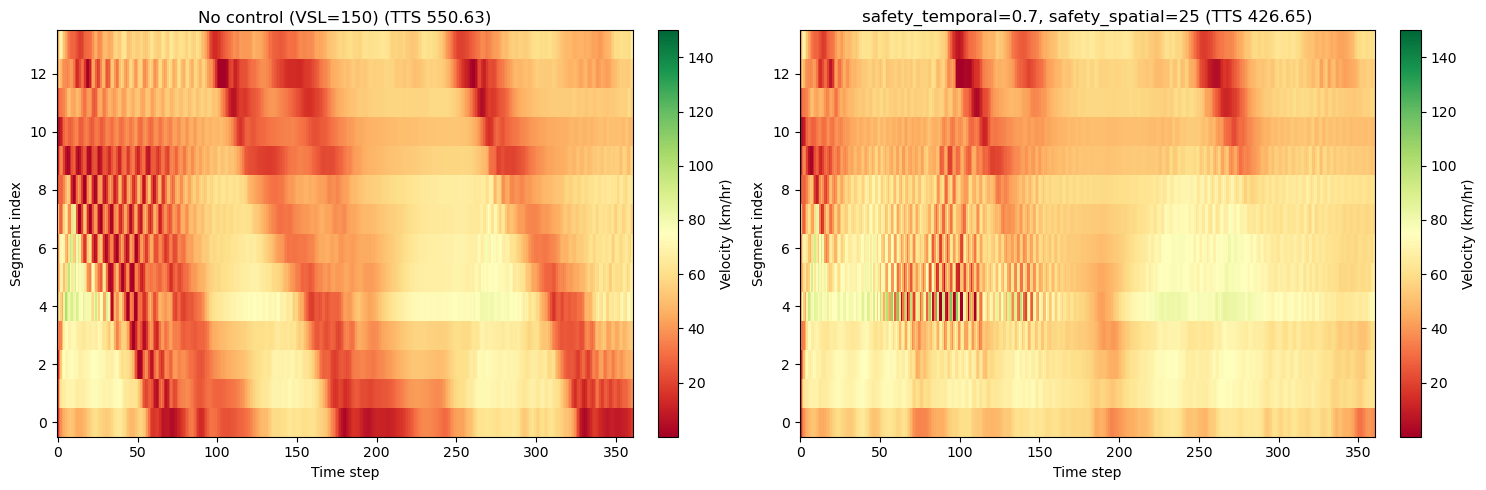

In [ ]:
import json
from traffic_flow.solvers.mpc import mpc_find_vsl

os.makedirs(results_path, exist_ok=True)

for safety_temporal in reversed(safety_temporal_values):
    # init_path = None
    for safety_spatial in reversed(safety_spatial_values):
        init_path = f"{results_path}/optimal_vsl_temp0.9_spat25.npy"
        # if f'optimal_vsl_temp{safety_temporal}_spat{safety_spatial}.npy' in os.listdir(results_path):
        #     print(f"Skipping safety_temporal={safety_temporal}, safety_spatial={safety_spatial} (already exists)")
        #     # init_path = f'{results_path}/optimal_vsl_temp{safety_temporal}_spat{safety_spatial}.npy'
        #     continue

        vsl_opt_config = {
            "hold_length": hold_len,
            "control_changepoints": None,
            "safety_temporal": safety_temporal,
            "safety_spatial": safety_spatial,
            "speed_lb": 0,
            "warmup_time": 0,
            "control_zone": control_zone,
            "control_one_segment": None,
            "initialize_vsl":np.load(init_path),
            "init_fixed": ["adaptive", 120, 100, 80, 60, 40], #"adaptive",
            "tee": False,
            "pred_horizon": pred_horizon,
            "control_horizon": control_horizon
        }

        print(f"\n=== safety_temporal={safety_temporal}, safety_spatial={safety_spatial} ===")
        optimal_vsl = mpc_find_vsl(opt_horizon, inflow_mpc[start_time:], downstream_density_mpc[start_time:], lane_dict,
                                T=time_step, l=L, num_segments=num_segments, init_state=init_state,
                                params=model_params, verbose=True, v_fd_penalty=1e14, **vsl_opt_config)

        path_id = f"optimal_vsl_temp{safety_temporal}_spat{safety_spatial}"
        np.save(f'{results_path}/{path_id}.npy', optimal_vsl)
        if vsl_opt_config["initialize_vsl"] is not None:
            vsl_opt_config["initialize_vsl"] = f"loaded from file {init_path}"
        with open(f'{results_path}/{path_id}_config.json', "w") as file:
            json.dump(vsl_opt_config, file, indent=4)

        # Simulate forward with the optimized VSL to get the "after control" trajectory
        p_after, v_after, queue_after, tts_after = sim.run_with_history(
            data_inflow[start_time:], downstream_density[start_time:], init_state, vsl_speeds=optimal_vsl
        )

        print(f"TTS (no control):                                                  {tts_baseline}")
        print(f"TTS (safety_temporal={safety_temporal}, safety_spatial={safety_spatial}): {tts_after}")

        plot_before_after(v_baseline, tts_baseline, v_after, tts_after,
                           "No control (VSL=150)",
                           f"safety_temporal={safety_temporal}, safety_spatial={safety_spatial}")
        
        # init_path = f'{results_path}/optimal_vsl_temp{safety_temporal}_spat{safety_spatial}.npy'